In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import LabelEncoder

**Q1 Inspect dataset**

In [2]:
df = pd.read_csv("/content/9064 mixed_ecommerce_dataset - 9064 mixed_ecommerce_dataset.csv")

df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   OrderID          15 non-null     int64 
 1   CustomerName     15 non-null     object
 2   Gender           15 non-null     object
 3   Product          15 non-null     object
 4   Category         15 non-null     object
 5   Quantity         15 non-null     int64 
 6   UnitPrice        15 non-null     int64 
 7   DiscountPercent  15 non-null     int64 
 8   ShippingCost     15 non-null     int64 
 9   TaxAmount        15 non-null     int64 
 10  TotalAmount      15 non-null     int64 
 11  PaymentMode      15 non-null     object
 12  City             15 non-null     object
 13  OrderMonth       15 non-null     object
 14  DeliveryDays     15 non-null     int64 
dtypes: int64(8), object(7)
memory usage: 1.9+ KB


**Q2 Check missing values**

In [3]:
df.isnull().sum()

,0
OrderID,0
CustomerName,0
Gender,0
Product,0
Category,0
Quantity,0
UnitPrice,0
DiscountPercent,0
ShippingCost,0
TaxAmount,0


**Q3 Verify TotalAmount formula**

In [5]:
df["calculated_total"] = (df["Quantity"] * df["UnitPrice"]
                          * (1 - df["DiscountPercent"] / 100)
                          + df["ShippingCost"]
                          + df["TaxAmount"])

df[df["TotalAmount"] != df["calculated_total"]]

,OrderID,CustomerName,Gender,Product,Category,Quantity,UnitPrice,DiscountPercent,ShippingCost,TaxAmount,TotalAmount,PaymentMode,City,OrderMonth,DeliveryDays,calculated_total
0,1001,Cust_1,Female,Phone,Accessories,9,6601,14,430,4865,47808,Card,Pune,May,2,56386.74
1,1002,Cust_2,Male,Headphones,Electronics,3,39667,13,183,2044,33011,UPI,Mumbai,Feb,14,105757.87
2,1003,Cust_3,Female,Headphones,Accessories,5,44870,19,154,1860,59906,Cash,Mumbai,May,6,183737.50
3,1004,Cust_4,Male,Laptop,Accessories,2,35892,13,143,3085,35594,Cash,Chennai,Feb,1,65680.08
4,1005,Cust_5,Female,Headphones,Accessories,7,7105,24,123,2541,69543,NetBanking,Mumbai,Apr,5,40462.60
5,1006,Cust_6,Female,Laptop,Electronics,2,6446,3,478,2060,31706,UPI,Delhi,Mar,4,15043.24
6,1007,Cust_7,Female,Phone,Electronics,6,48894,7,233,2201,44850,NetBanking,Pune,Apr,8,275262.52
7,1008,Cust_8,Female,Laptop,Accessories,2,27122,32,345,4018,28843,Cash,Pune,Jan,5,41248.92
8,1009,Cust_9,Male,Laptop,Electronics,7,30632,33,256,1226,31855,UPI,Delhi,Jan,14,145146.08
9,1010,Cust_10,Female,Keyboard,Electronics,9,20462,11,240,2293,53026,UPI,Delhi,Mar,13,166433.62


**Q4 Standardize text columns**

In [7]:
df["Category"] = df["Category"].str.lower()
df["City"] = df["City"].str.lower()

print("Category column after converting to lowercase:")
print(df["Category"].head())

print("\nCity column after converting to lowercase:")
print(df["City"].head())

Category column after converting to lowercase:
0    accessories
1    electronics
2    accessories
3    accessories
4    accessories
Name: Category, dtype: object

City column after converting to lowercase:
0       pune
1     mumbai
2     mumbai
3    chennai
4     mumbai
Name: City, dtype: object


**Q5 Remove duplicate OrderID**

In [9]:
df = df.drop_duplicates(subset="OrderID")
print("Shape After Removing Duplicates:", df.shape)

Shape After Removing Duplicates: (15, 16)


**Q6 Detect Outliers (Boxplot)**

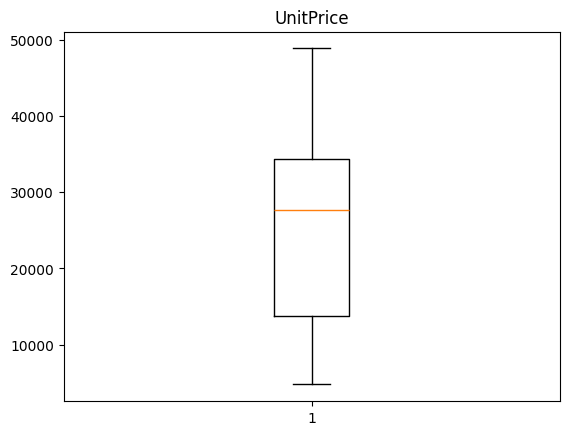

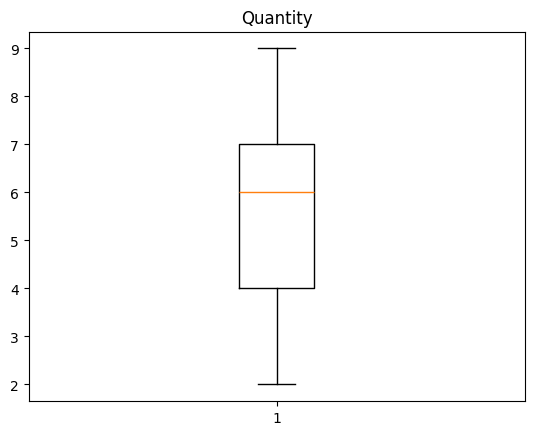

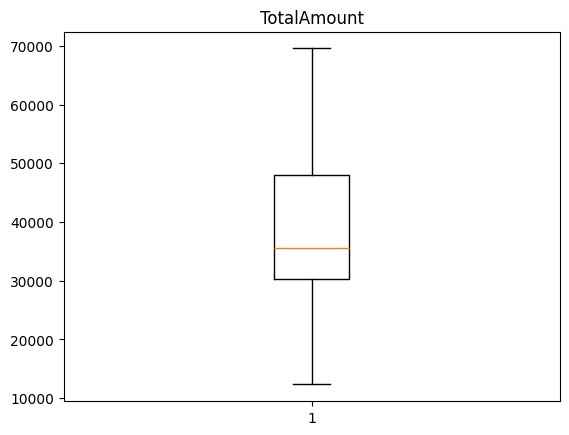

In [11]:
plt.boxplot(df["UnitPrice"])
plt.title("UnitPrice")
plt.show()

plt.boxplot(df["Quantity"])
plt.title("Quantity")
plt.show()

plt.boxplot(df["TotalAmount"])
plt.title("TotalAmount")
plt.show()

**Q7 Convert OrderMonth to Categorical**

In [13]:
df["OrderMonth"] = pd.Categorical(
    df["OrderMonth"],
    categories=["Jan","Feb","Mar","Apr","May","Jun",
                "Jul","Aug","Sep","Oct","Nov","Dec"],
    ordered=True
)

print("OrderMonth Converted to Categorical")

OrderMonth Converted to Categorical


**Q8 Create DiscountAmount**

In [15]:
df["discountAmount"] = (df["UnitPrice"] * df["DiscountPercent"]) / 100

print("DiscountAmount column created successfully.")
print(df[["UnitPrice", "DiscountPercent", "discountAmount"]].head())

DiscountAmount column created successfully.
   UnitPrice  DiscountPercent  discountAmount
0       6601               14          924.14
1      39667               13         5156.71
2      44870               19         8525.30
3      35892               13         4665.96
4       7105               24         1705.20


**Q9 Create NetSales**

In [17]:
df["netsales"] = df["TotalAmount"] - df["ShippingCost"] - df["TaxAmount"]

print("NetSales column created successfully.")
print(df[["TotalAmount", "ShippingCost", "TaxAmount", "netsales"]].head())

NetSales column created successfully.
   TotalAmount  ShippingCost  TaxAmount  netsales
0        47808           430       4865     42513
1        33011           183       2044     30784
2        59906           154       1860     57892
3        35594           143       3085     32366
4        69543           123       2541     66879


**Q10 Rename columns (snake_case)**

In [18]:
df.columns = df.columns.str.lower().str.replace(" ", "_")

print("Columns renamed to snake_case successfully.")
print("Updated Column Names:")
print(df.columns)

Columns renamed to snake_case successfully.
Updated Column Names:
Index(['orderid', 'customername', 'gender', 'product', 'category', 'quantity',
       'unitprice', 'discountpercent', 'shippingcost', 'taxamount',
       'totalamount', 'paymentmode', 'city', 'ordermonth', 'deliverydays',
       'calculated_total', 'discountamount', 'netsales'],
      dtype='object')


**Q11 Check negative values**

In [19]:
invalid_values = df[(df["quantity"] <= 0) |
                    (df["unitprice"] <= 0) |
                    (df["totalamount"] <= 0)]

print("Records with Negative or Zero Values:")
print(invalid_values)

Records with Negative or Zero Values:
Empty DataFrame
Columns: [orderid, customername, gender, product, category, quantity, unitprice, discountpercent, shippingcost, taxamount, totalamount, paymentmode, city, ordermonth, deliverydays, calculated_total, discountamount, netsales]
Index: []


**Q12 Encode Gender & PaymentMode**

In [20]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df["gender"] = le.fit_transform(df["gender"])
df["paymentmode"] = le.fit_transform(df["paymentmode"])

print("Encoding completed successfully.")

print("\nEncoded Gender Values:")
print(df["gender"].head())

print("\nEncoded PaymentMode Values:")
print(df["paymentmode"].head())

Encoding completed successfully.

Encoded Gender Values:
0    0
1    1
2    0
3    1
4    0
Name: gender, dtype: int64

Encoded PaymentMode Values:
0    0
1    3
2    1
3    1
4    2
Name: paymentmode, dtype: int64


**EXPLORATORY DATA ANALYSIS**

**Q13 Total Revenue**

In [21]:
total_revenue = df["totalamount"].sum()
print("Total Revenue:", total_revenue)

Total Revenue: 584576


**Q14 Highest Sales Category**

In [22]:
df.groupby("category")["totalamount"].sum()

,totalamount
category,
accessories,316006
electronics,268570


**Q15 Average Order Value (AOV)**

In [23]:
aov = df["totalamount"].mean()
print("Average Order Value:", aov)

Average Order Value: 38971.73333333333


**Q16 Month-wise Sales Trend**

/tmp/ipython-input-3838794165.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("ordermonth")["totalamount"].sum().plot(kind="bar")


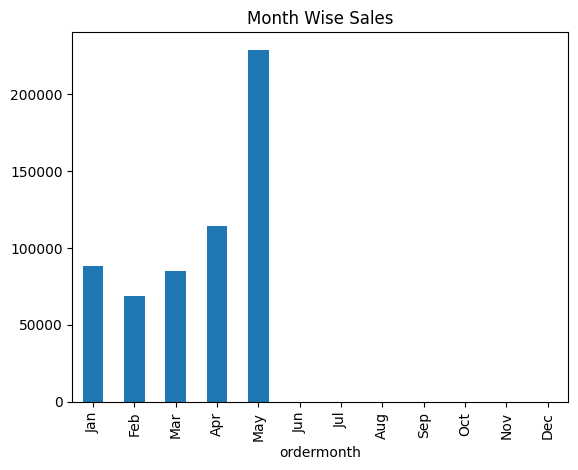

In [24]:
df.groupby("ordermonth")["totalamount"].sum().plot(kind="bar")
plt.title("Month Wise Sales")
plt.show()

**Q17 City with Maximum Revenue**

In [25]:
df.groupby("city")["totalamount"].sum()

,totalamount
city,
chennai,63036
delhi,178563
mumbai,209140
pune,133837


**Q18 Male vs Female Spending**

In [26]:
df.groupby("gender")["totalamount"].sum()

,totalamount
gender,
0,377037
1,207539


**Q19 Most Used Payment Mode**

In [27]:
df["paymentmode"].value_counts()

,count
paymentmode,
3,7
1,4
2,3
0,1


**Q20 Top 3 Revenue Products**

In [28]:
df.groupby("product")["totalamount"].sum().sort_values(ascending=False).head(3)

,totalamount
product,
Headphones,210523
Laptop,127998
Keyboard,127148


**Q21 Discount vs TotalAmount**

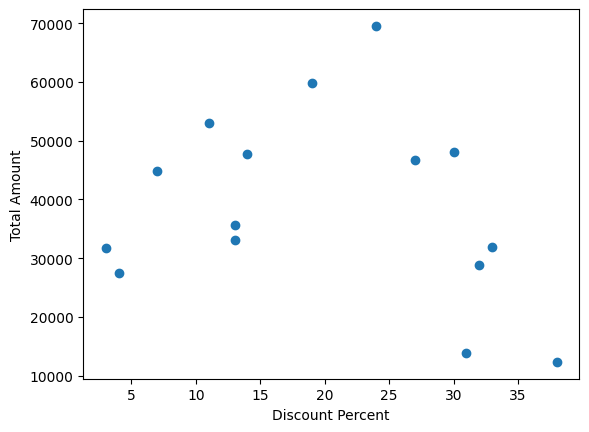

In [29]:
plt.figure()
plt.scatter(df["discountpercent"], df["totalamount"])
plt.xlabel("Discount Percent")
plt.ylabel("Total Amount")
plt.show()

**Q22 Avg UnitPrice per Product**

In [30]:
df.groupby("product")["unitprice"].mean()

,unitprice
product,
Headphones,29844.500000
Keyboard,16260.333333
Laptop,25023.000000
Phone,29406.666667
Tablet,32252.000000


**Q23 Category-wise Quantity**

In [31]:
df.groupby("category")["quantity"].sum()

,quantity
category,
accessories,44
electronics,40


**Q24 Pivot Table**

In [32]:
pd.pivot_table(df,
               values="totalamount",
               index="city",
               columns="paymentmode",
               aggfunc="sum")

paymentmode,0,1,2,3
city,,,,
chennai,NaN,35594.0,27442.0,NaN
delhi,NaN,48063.0,NaN,130500.0
mumbai,NaN,59906.0,69543.0,79691.0
pune,47808.0,28843.0,44850.0,12336.0


**MODEL TRAINING**

**Feature Selection**

In [33]:
X = df[["quantity","unitprice","discountpercent",
        "shippingcost","taxamount","gender","paymentmode"]]

y = df["totalamount"]

print("Feature Selection Completed")

Feature Selection Completed


**Train Test Split**

In [34]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=9064)

print("Train-Test Split Completed")

Train-Test Split Completed


**Linear Regression Model**

In [35]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

**Prediction**

In [36]:
y_pred = model.predict(X_test)
print("Prediction Completed")

Prediction Completed


In [37]:
y_pred

array([59053.47016245, 48210.6475637 , 52626.59433471])

In [38]:
X_test

,quantity,unitprice,discountpercent,shippingcost,taxamount,gender,paymentmode
13,6,32725,31,291,387,0,3
6,6,48894,7,233,2201,0,2
0,9,6601,14,430,4865,0,0


In [39]:
y_test

,totalamount
13,13913
6,44850
0,47808


In [40]:
X_train

,quantity,unitprice,discountpercent,shippingcost,taxamount,gender,paymentmode
9,9,20462,11,240,2293,0,3
3,2,35892,13,143,3085,1,1
4,7,7105,24,123,2541,0,2
7,2,27122,32,345,4018,0,1
10,7,23567,27,436,1198,1,3
14,5,27736,30,352,2227,1,1
12,8,32252,38,392,4876,1,3
8,7,30632,33,256,1226,1,3
5,2,6446,3,478,2060,0,3
2,5,44870,19,154,1860,0,1


In [41]:
y_train

,totalamount
9,53026
3,35594
4,69543
7,28843
10,46680
14,48063
12,12336
8,31855
5,31706
2,59906


**Remove MAE MSE RMSE Error**

In [42]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)

MAE: 17773.237353620254
MSE: 690724949.9655818
RMSE: 26281.64663725585
